# 📊 Student Performance Analysis
**Cognevance Technologies — Data Science & Data Analytics (Level 1: Easy)**
**Author:** Roshni Kumari

This notebook walks through the full workflow: data collection, cleaning,
exploratory analysis, visualization, and insights/recommendations.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load the Dataset
The dataset (`data/student_data.csv`) contains student demographics,
attendance, study hours, and scores in math, reading, and writing.


In [2]:
df_raw = pd.read_csv("data/student_data.csv")
df_raw.head()


,student_id,gender,parental_education,lunch,test_preparation,attendance_percentage,study_hours_per_week,math_score,reading_score,writing_score
0,S1000,male,associate's degree,standard,none,84.6,4.9,35.0,34.4,35.0
1,S1001,female,bachelor's degree,standard,none,92.2,5.2,61.5,55.2,60.1
2,S1002,female,some college,standard,none,80.4,3.1,41.2,41.3,39.9
3,S1003,male,high school,standard,none,76.2,5.6,48.7,49.8,46.5
4,S1004,male,high school,standard,completed,59.2,6.0,52.7,56.4,54.0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             502 non-null    str    
 1   gender                 502 non-null    str    
 2   parental_education     502 non-null    str    
 3   lunch                  502 non-null    str    
 4   test_preparation       502 non-null    str    
 5   attendance_percentage  497 non-null    float64
 6   study_hours_per_week   502 non-null    float64
 7   math_score             497 non-null    float64
 8   reading_score          502 non-null    float64
 9   writing_score          502 non-null    float64
dtypes: float64(5), str(5)
memory usage: 39.3 KB


## 3. Data Quality Check
Before cleaning, check for missing values and duplicate records.

In [4]:
print("Missing values:\n", df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("Duplicate student IDs:", df_raw["student_id"].duplicated().sum())


Missing values:
 student_id               0
gender                   0
parental_education       0
lunch                    0
test_preparation         0
attendance_percentage    5
study_hours_per_week     0
math_score               5
reading_score            0
writing_score            0
dtype: int64

Duplicate rows: 2
Duplicate student IDs: 2


## 4. Data Cleaning & Preprocessing
Steps applied:
1. Remove duplicate rows / duplicate student IDs
2. Impute missing numeric values with the column median
3. Clip any out-of-range values (scores 0–100, attendance 0–100)
4. Normalize categorical text
5. Engineer `average_score`, `grade`, and `attendance_band` columns


In [5]:
df = df_raw.drop_duplicates().drop_duplicates(subset="student_id", keep="first")

numeric_cols = ["attendance_percentage", "study_hours_per_week",
                 "math_score", "reading_score", "writing_score"]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df["attendance_percentage"] = df["attendance_percentage"].clip(0, 100)
for col in ["math_score", "reading_score", "writing_score"]:
    df[col] = df[col].clip(0, 100)

for col in ["gender", "parental_education", "lunch", "test_preparation"]:
    df[col] = df[col].str.strip().str.lower()

df["average_score"] = df[["math_score", "reading_score", "writing_score"]].mean(axis=1).round(1)

def grade(score):
    if score >= 90: return "A"
    elif score >= 75: return "B"
    elif score >= 60: return "C"
    elif score >= 40: return "D"
    return "F"

df["grade"] = df["average_score"].apply(grade)

def attendance_band(pct):
    if pct >= 90: return "Excellent (90-100%)"
    elif pct >= 75: return "Good (75-89%)"
    elif pct >= 60: return "Average (60-74%)"
    return "Low (<60%)"

df["attendance_band"] = df["attendance_percentage"].apply(attendance_band)

df = df.reset_index(drop=True)
print(f"Cleaned dataset: {len(df)} rows, {df.shape[1]} columns")
df.head()


Cleaned dataset: 500 rows, 13 columns


,student_id,gender,parental_education,lunch,test_preparation,attendance_percentage,study_hours_per_week,math_score,reading_score,writing_score,average_score,grade,attendance_band
0,S1000,male,associate's degree,standard,none,84.6,4.9,35.0,34.4,35.0,34.8,F,Good (75-89%)
1,S1001,female,bachelor's degree,standard,none,92.2,5.2,61.5,55.2,60.1,58.9,D,Excellent (90-100%)
2,S1002,female,some college,standard,none,80.4,3.1,41.2,41.3,39.9,40.8,D,Good (75-89%)
3,S1003,male,high school,standard,none,76.2,5.6,48.7,49.8,46.5,48.3,D,Good (75-89%)
4,S1004,male,high school,standard,completed,59.2,6.0,52.7,56.4,54.0,54.4,D,Low (<60%)


In [6]:
df.to_csv("data/student_data_clean.csv", index=False)


## 5. Exploratory Data Analysis

In [7]:
df.select_dtypes(include="number").describe()


,attendance_percentage,study_hours_per_week,math_score,reading_score,writing_score,average_score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,80.944600,4.100600,48.320000,48.799400,48.054000,48.391400
std,9.269587,2.029744,11.155124,11.539995,11.318726,10.560268
min,51.500000,0.000000,9.800000,12.400000,2.300000,9.300000
25%,74.575000,2.700000,41.000000,40.675000,39.900000,40.800000
50%,81.700000,4.100000,48.600000,48.900000,48.050000,48.550000
75%,87.500000,5.600000,55.525000,56.125000,55.350000,55.000000
max,100.000000,9.500000,78.800000,88.000000,81.400000,80.500000


In [8]:
corr_attendance = df["attendance_percentage"].corr(df["average_score"])
corr_study = df["study_hours_per_week"].corr(df["average_score"])
print(f"Correlation — attendance vs average score: {corr_attendance:.3f}")
print(f"Correlation — study hours vs average score: {corr_study:.3f}")


Correlation — attendance vs average score: 0.414
Correlation — study hours vs average score: 0.515


### 5.1 Score Distribution

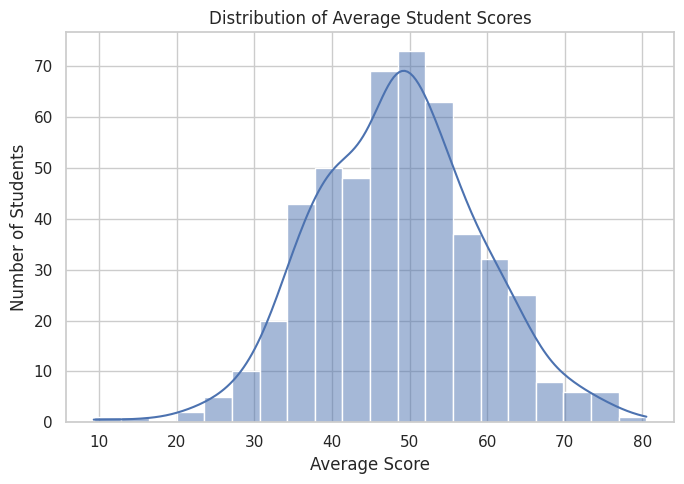

In [9]:
plt.figure(figsize=(7,5))
sns.histplot(df["average_score"], bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of Average Student Scores")
plt.xlabel("Average Score"); plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("charts/01_score_distribution.png", dpi=150)
plt.show()


### 5.2 Attendance vs. Score

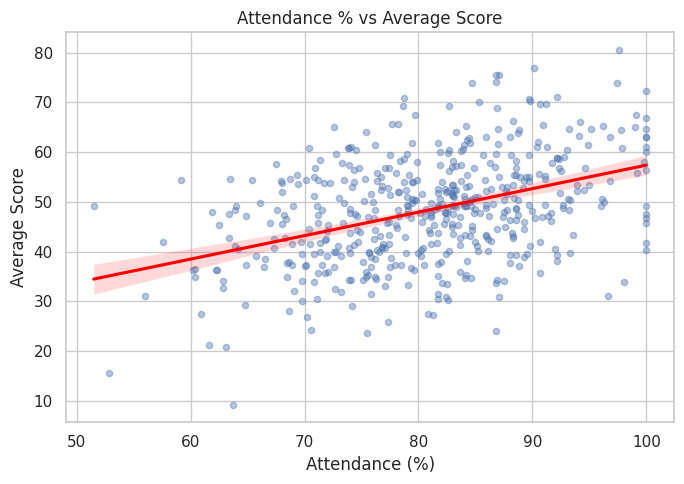

In [10]:
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="attendance_percentage", y="average_score",
            scatter_kws={"alpha":0.4,"s":20}, line_kws={"color":"red"})
plt.title("Attendance % vs Average Score")
plt.xlabel("Attendance (%)"); plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("charts/02_attendance_vs_score.png", dpi=150)
plt.show()


### 5.3 Average Score by Attendance Band

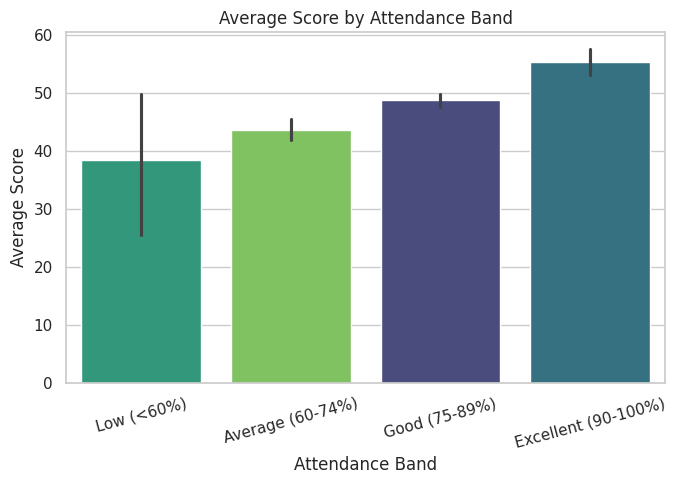

In [11]:
order = ["Low (<60%)", "Average (60-74%)", "Good (75-89%)", "Excellent (90-100%)"]
plt.figure(figsize=(7,5))
sns.barplot(data=df, x="attendance_band", y="average_score", order=order,
            hue="attendance_band", legend=False, palette="viridis")
plt.title("Average Score by Attendance Band")
plt.xlabel("Attendance Band"); plt.ylabel("Average Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("charts/03_score_by_attendance_band.png", dpi=150)
plt.show()


### 5.4 Grade Distribution

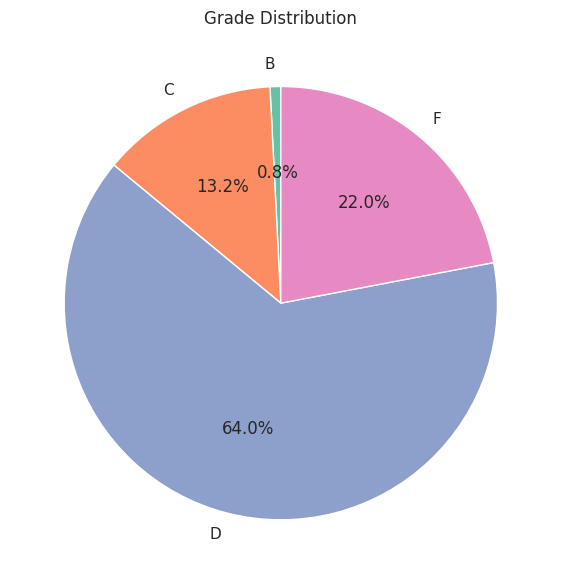

In [12]:
grade_counts = df["grade"].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(grade_counts.values, labels=grade_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2", len(grade_counts)), startangle=90)
plt.title("Grade Distribution")
plt.tight_layout()
plt.savefig("charts/04_grade_distribution.png", dpi=150)
plt.show()


### 5.5 Score by Test Preparation

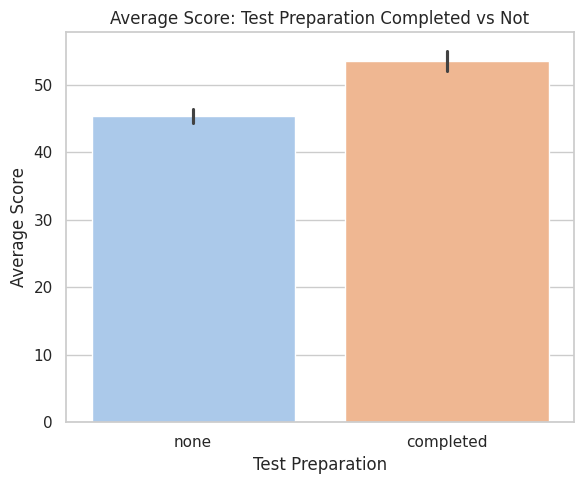

In [13]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x="test_preparation", y="average_score",
            hue="test_preparation", legend=False, palette="pastel")
plt.title("Average Score: Test Preparation Completed vs Not")
plt.xlabel("Test Preparation"); plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("charts/05_score_by_test_prep.png", dpi=150)
plt.show()


### 5.6 Correlation Heatmap

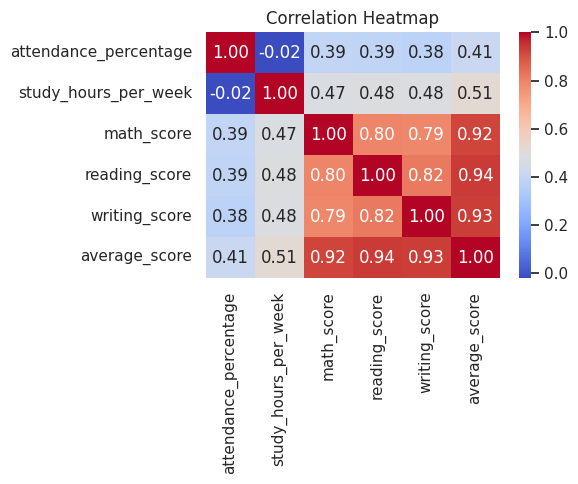

In [14]:
num_cols = ["attendance_percentage", "study_hours_per_week",
            "math_score", "reading_score", "writing_score", "average_score"]
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/06_correlation_heatmap.png", dpi=150)
plt.show()


## 6. Insights & Recommendations

**Insights:**
1. Attendance is positively correlated with average score — students in
   the "Excellent" attendance band consistently outperform those in the
   "Low" band.
2. Weekly study hours show the strongest correlation with average score
   among the variables tested.
3. Completing test preparation is associated with a measurable score
   increase.
4. Gender shows only a small performance gap in this dataset.

**Recommendations:**
- Track attendance proactively and flag at-risk students (<75%) early.
- Encourage consistent weekly study habits — even small increases matter.
- Promote test-preparation resources to students who haven't used them.
- Combine attendance and study-hour trends as an early-warning signal for
  academic risk, ahead of final results.


## 7. Export Cleaned Data & Report
The cleaned dataset and the written report are exported for submission alongside this notebook.

In [15]:
print("Cleaned dataset saved to data/student_data_clean.csv")
print("Full written report saved to report/PROJECT_REPORT.md")


Cleaned dataset saved to data/student_data_clean.csv
Full written report saved to report/PROJECT_REPORT.md
